In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("mhealth_raw_data.csv")
df.sample(5)

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
166568,1.9032,-9.7629,-0.052446,-0.226350,-0.75235,0.646370,-3.06040,-8.1195,4.05240,-0.88627,-0.82752,0.34698,0,subject2
1009799,3.6261,-18.2270,-13.781000,0.562150,-0.75047,0.212180,-2.72390,-7.3276,0.23779,-0.40392,-0.59138,0.90733,0,subject9
944530,2.5886,-7.0427,-3.284600,-0.278290,-1.14630,0.033399,-0.93618,-8.8651,4.49420,-0.42157,-0.54825,0.96336,0,subject8
695393,2.1330,-13.1570,1.165600,-0.178110,-0.74672,-0.634580,-0.22163,-11.1620,6.77520,-0.29804,-1.04930,0.24569,0,subject6
733118,1.5616,-9.9069,2.374400,-0.012987,-0.06379,0.760310,-4.33970,-8.8340,1.60000,-0.81569,-0.18070,0.38578,0,subject6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215745 entries, 0 to 1215744
Data columns (total 14 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   alx       1215745 non-null  float64
 1   aly       1215745 non-null  float64
 2   alz       1215745 non-null  float64
 3   glx       1215745 non-null  float64
 4   gly       1215745 non-null  float64
 5   glz       1215745 non-null  float64
 6   arx       1215745 non-null  float64
 7   ary       1215745 non-null  float64
 8   arz       1215745 non-null  float64
 9   grx       1215745 non-null  float64
 10  gry       1215745 non-null  float64
 11  grz       1215745 non-null  float64
 12  Activity  1215745 non-null  int64  
 13  subject   1215745 non-null  object 
dtypes: float64(12), int64(1), object(1)
memory usage: 129.9+ MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alx,1215745.0,1.494200,3.826485,-22.1460,0.14131,1.308900,2.575800,20.0540
aly,1215745.0,-9.692878,4.171303,-19.6190,-10.20100,-9.670300,-9.042200,21.1610
alz,1215745.0,-0.954806,5.461803,-19.3730,-2.64940,-0.016456,1.301300,25.0150
glx,1215745.0,-0.001599,0.491217,-2.1466,-0.43599,-0.014842,0.448980,60.4840
gly,1215745.0,-0.616632,0.354641,-7.7899,-0.81801,-0.707320,-0.540340,2.0113
glz,1215745.0,-0.158781,0.546798,-2.6267,-0.59332,-0.190570,0.322200,2.7701
arx,1215745.0,-3.713413,4.763586,-22.3610,-6.07600,-2.977600,-1.193700,19.8640
ary,1215745.0,-5.805526,5.757639,-18.9720,-9.40420,-7.461500,-2.533900,22.1910
arz,1215745.0,2.393880,3.876503,-18.2390,0.12965,1.928100,4.914700,25.7410
grx,1215745.0,-0.276106,0.527689,-8.3392,-0.70588,-0.354900,0.096078,3.3196


In [5]:
df.isnull().sum()

alx         0
aly         0
alz         0
glx         0
gly         0
glz         0
arx         0
ary         0
arz         0
grx         0
gry         0
grz         0
Activity    0
subject     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

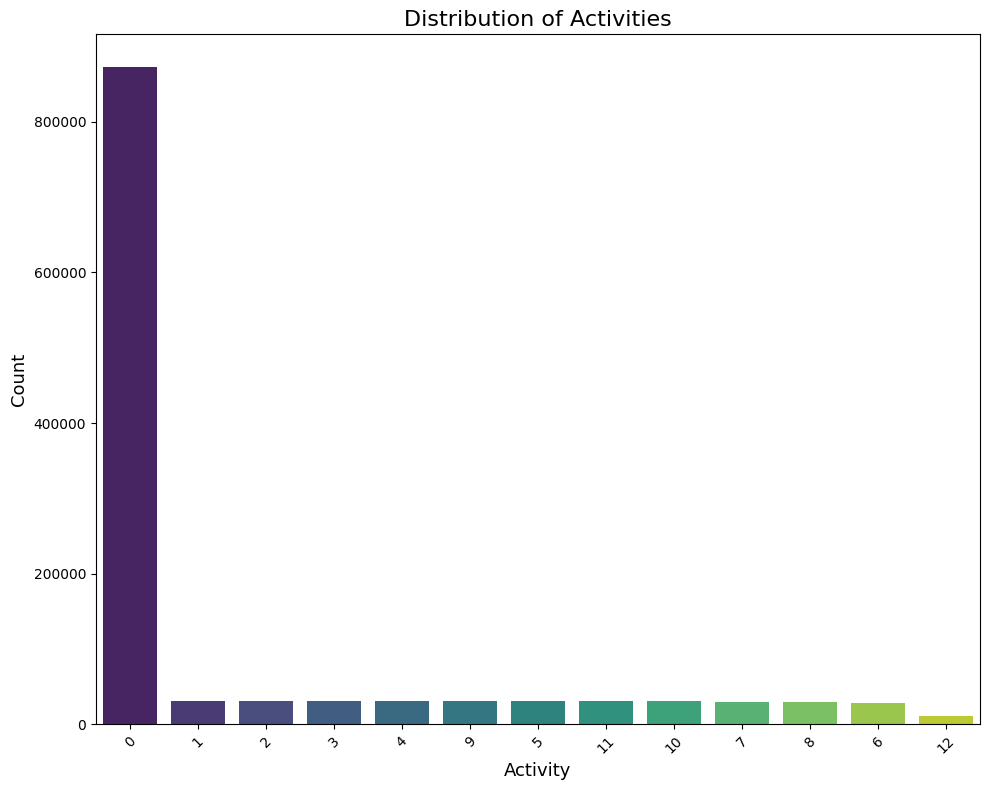

In [7]:
plt.figure(figsize=(10,8))

sns.countplot(
    x="Activity",
    data=df,
    palette="viridis",
    order=df["Activity"].value_counts().index
)

plt.title("Distribution of Activities", fontsize=16)
plt.xlabel("Activity", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [8]:
data_act_0 = df[df["Activity"] == 0]
data_act_else = df[df["Activity"] != 0]
data_act_0 = data_act_0.sample(n=30000, random_state=42)
df = pd.concat([data_act_0, data_act_else], ignore_index=True)

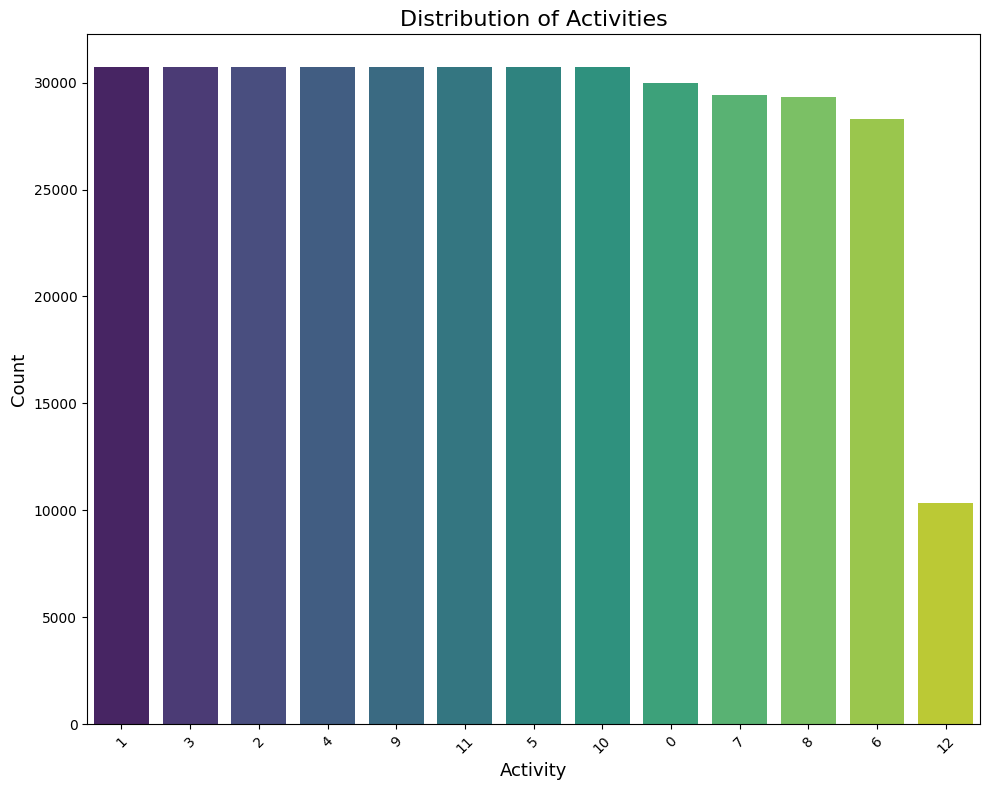

In [9]:
plt.figure(figsize=(10,8))
sns.countplot(
    x="Activity",
    data=df,
    palette="viridis",
    order=df["Activity"].value_counts().index
)
plt.title("Distribution of Activities", fontsize=16)
plt.xlabel("Activity", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
len(df)

373195

In [11]:
act_label = {
    0 : "None",
    1 : "Standing Still (1 min)",
    2 : "Sitting and Relaxing (1 min)",
    3 : "Lying Down (1 min)",
    4 : "Walking (1 min)",
    5 : "Climbing stairs (1 min)",
    6 : "Waist bends forward (20x)",
    7 : "Frontal elevation of arms (20x)",
    8 : "Knees bending (crouching) (20x)",
    9 : "Cycling (1 min)",
    10 : "Jogging (1 min)",
    11 : "Running (1 min)",
    12 : "Jump front & back (20x)"
}

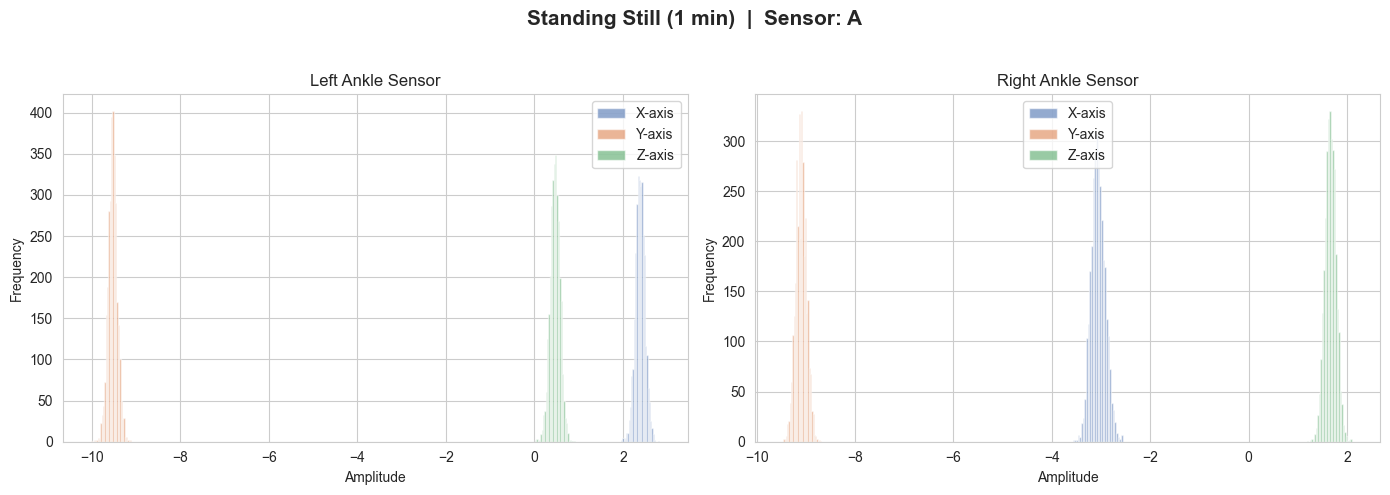

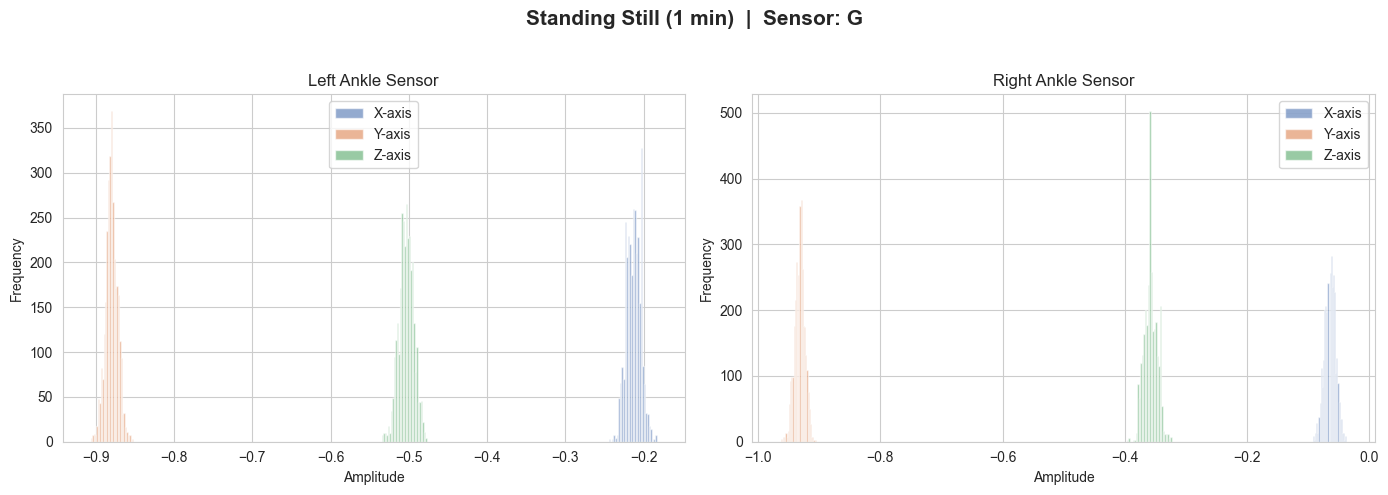

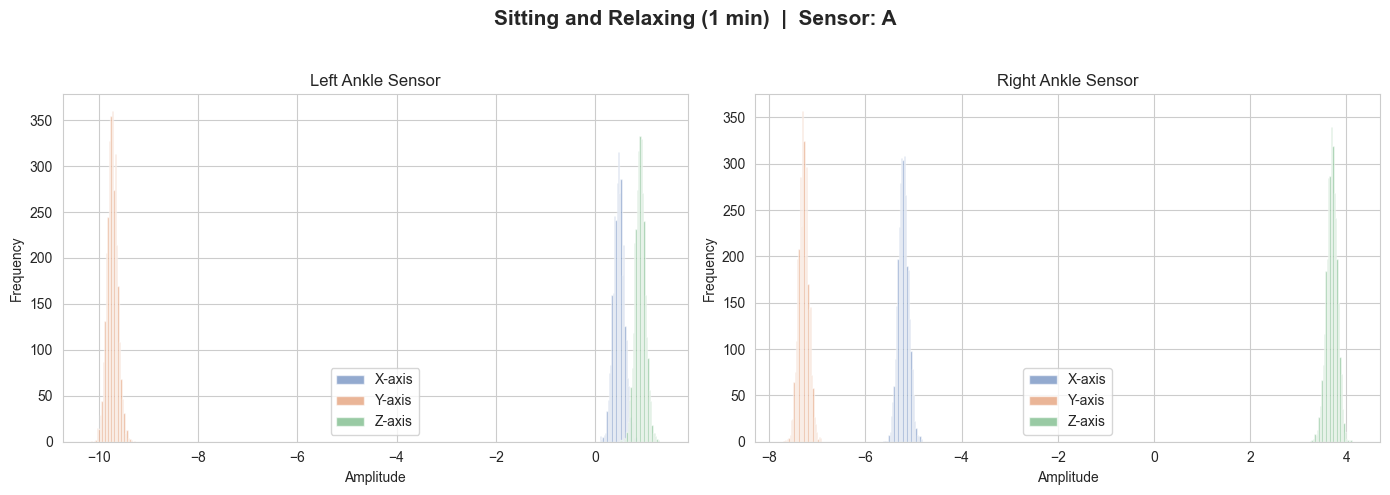

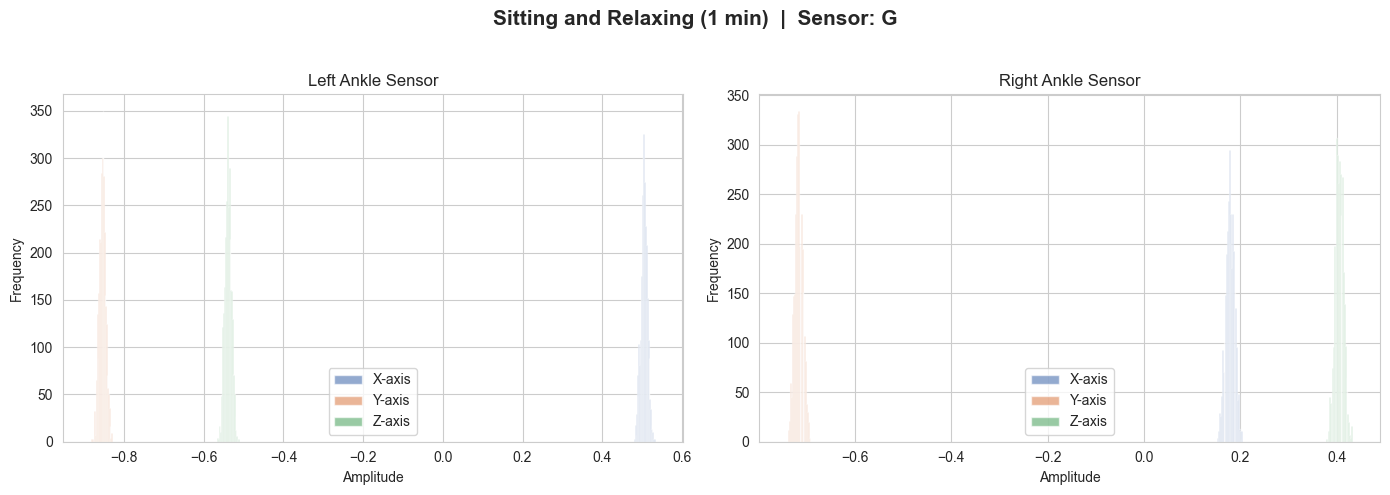

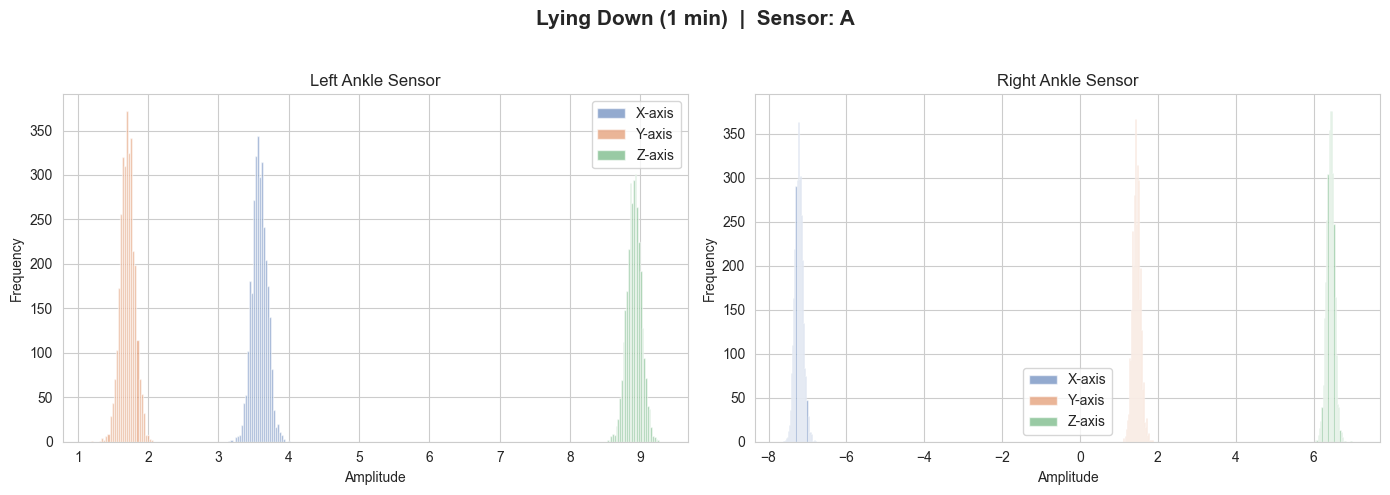

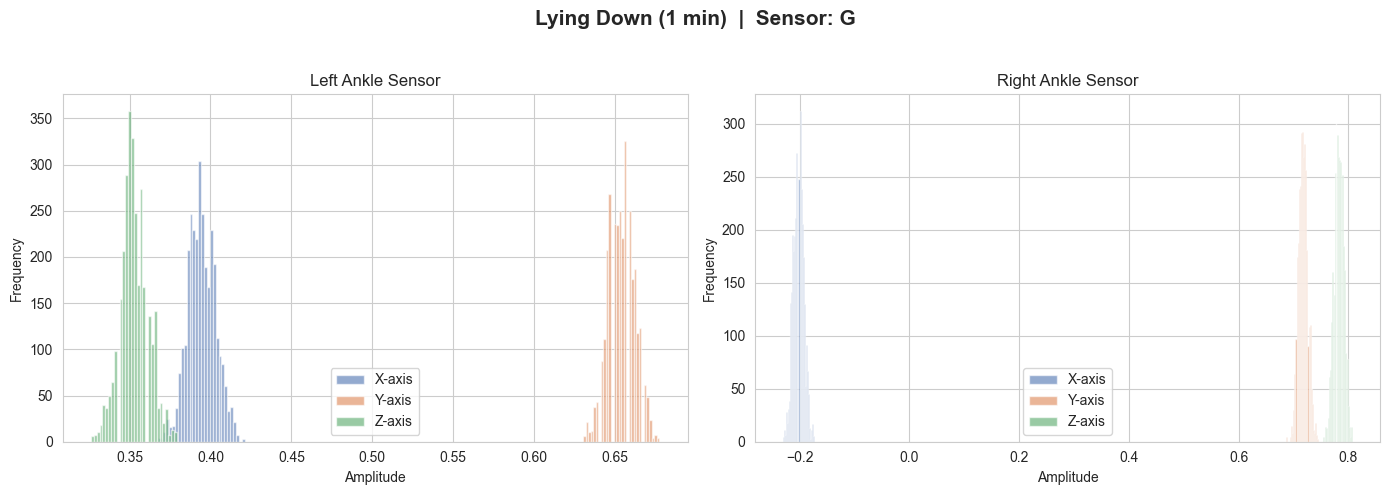

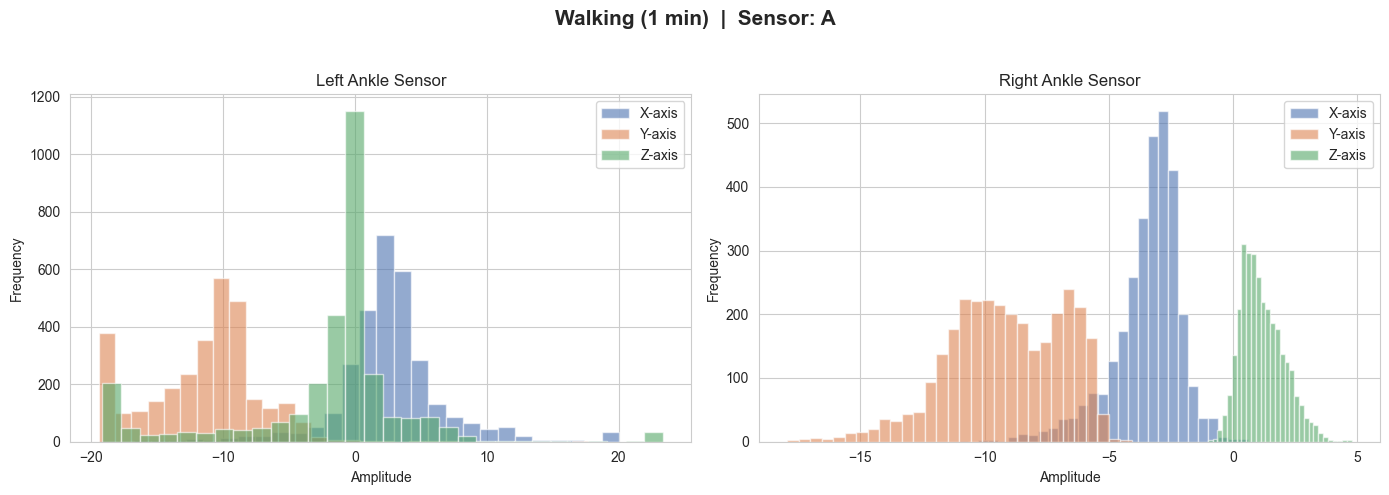

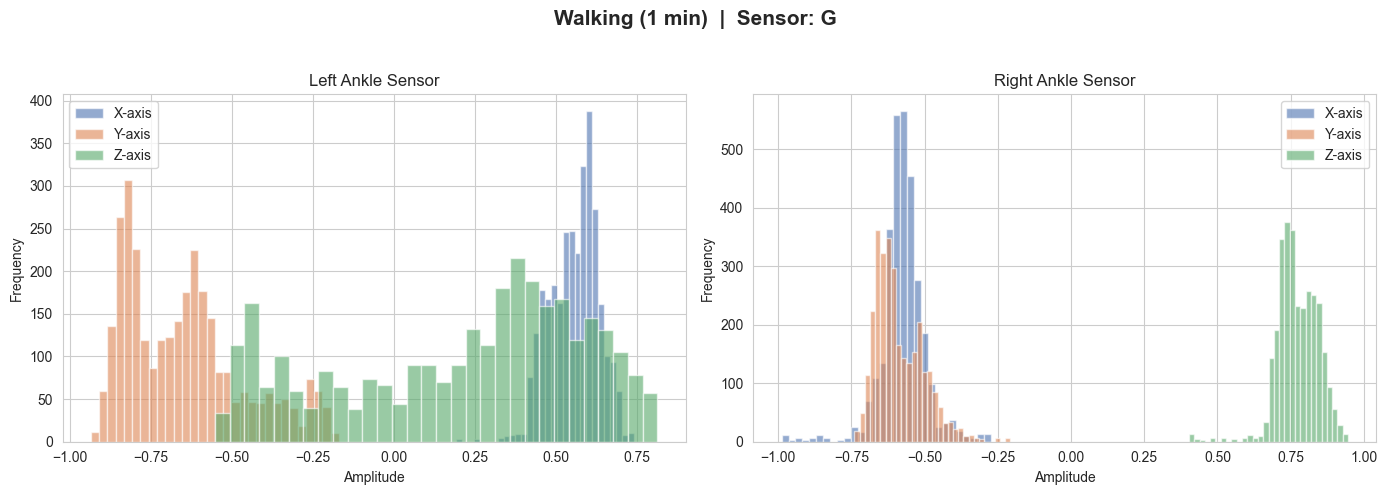

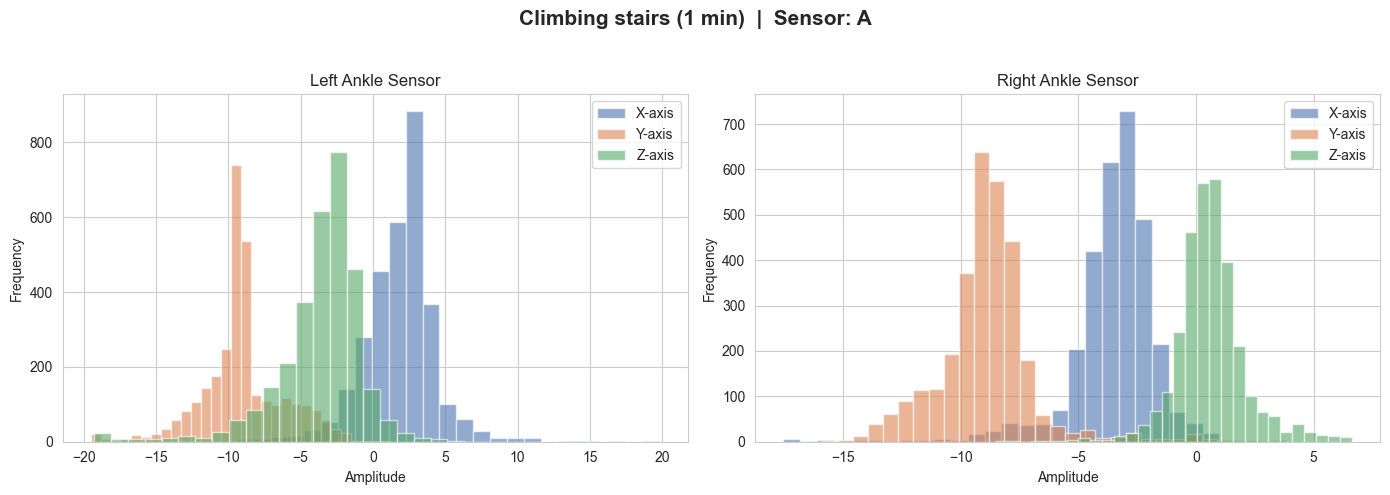

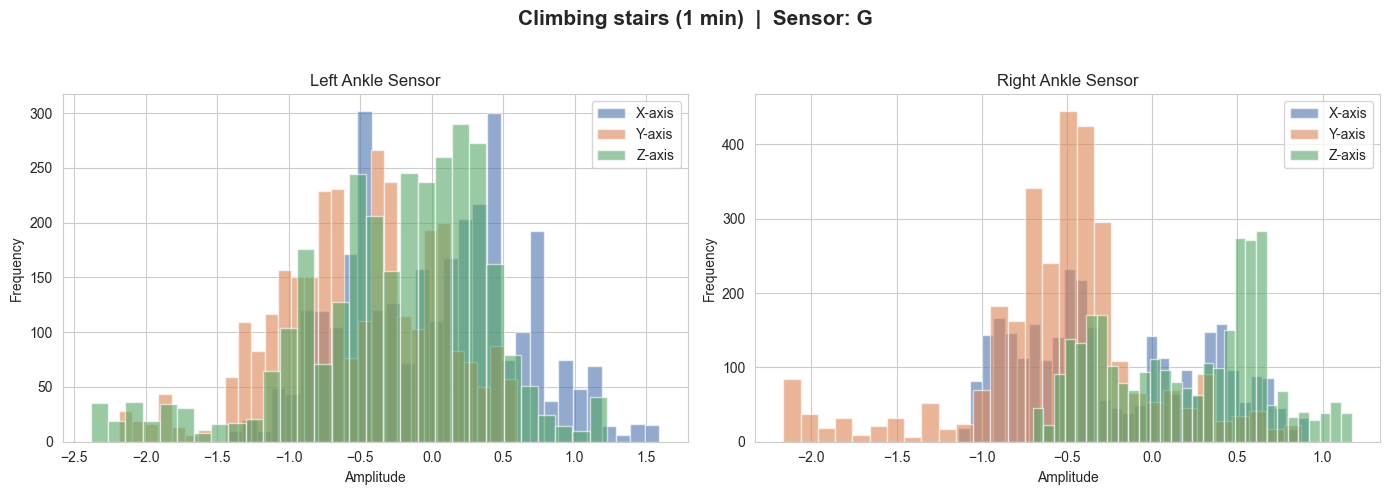

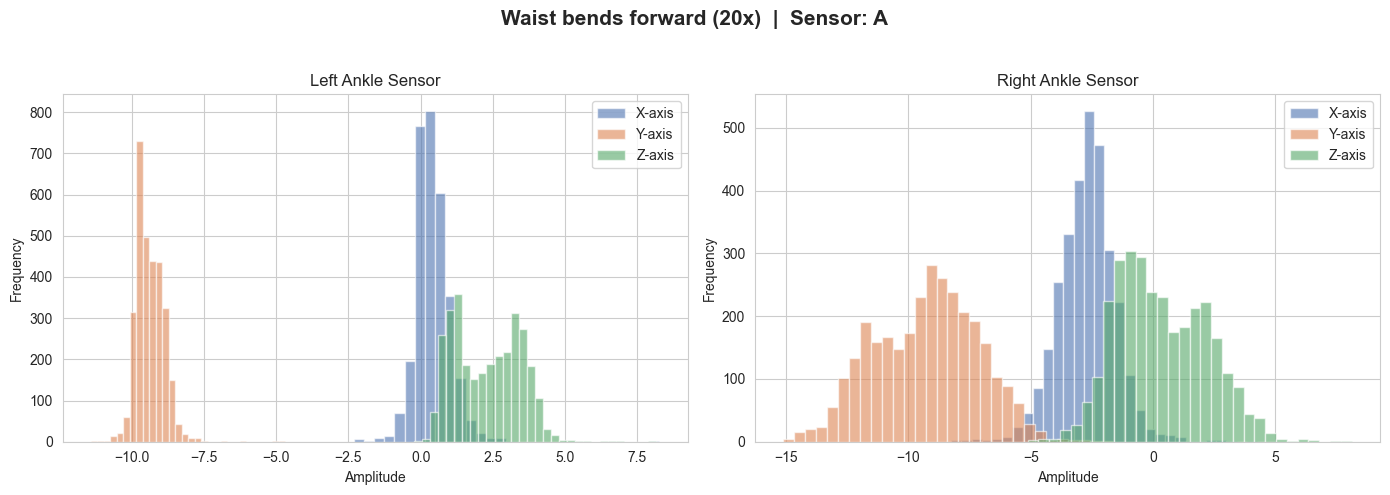

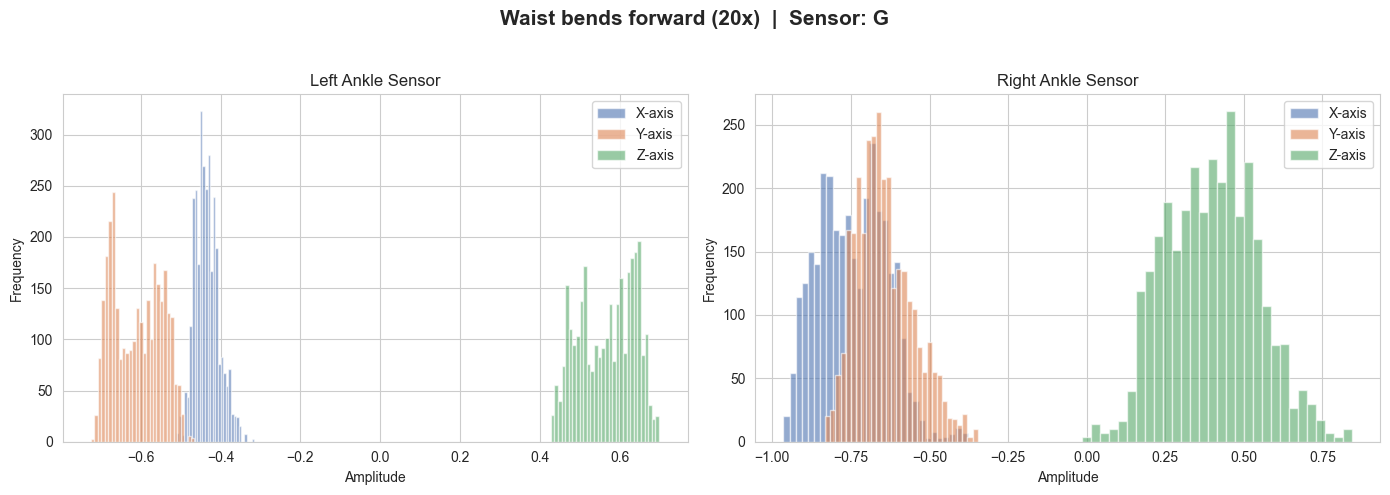

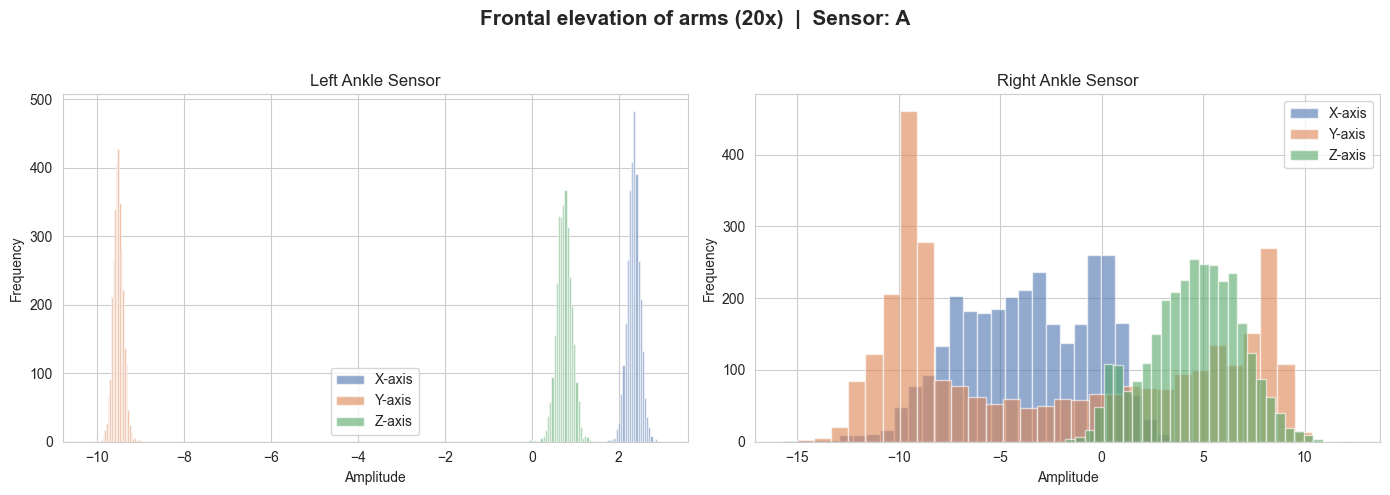

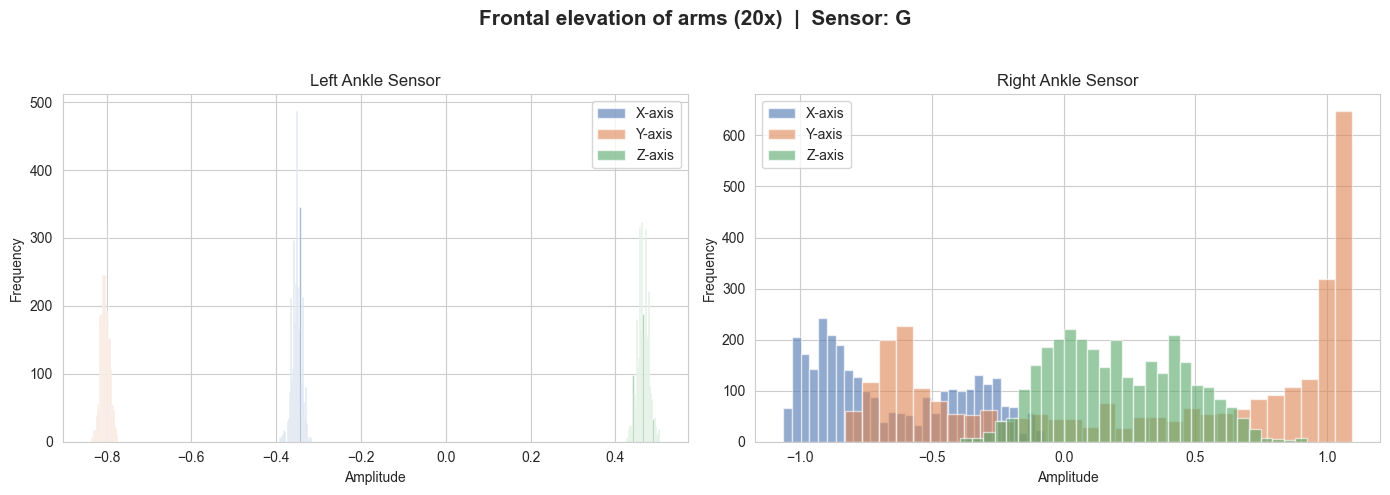

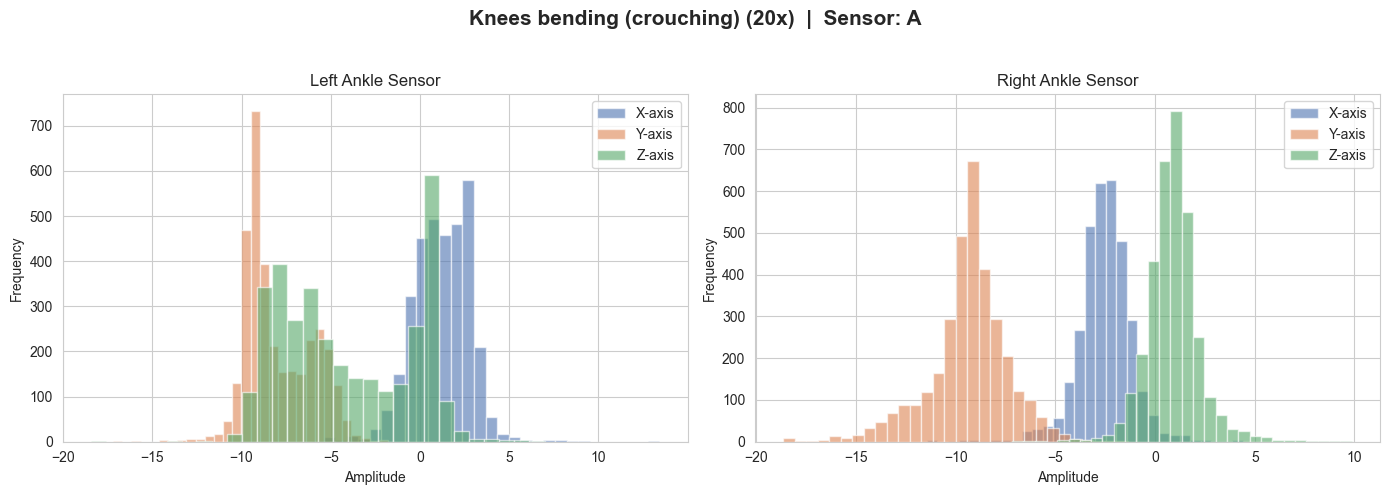

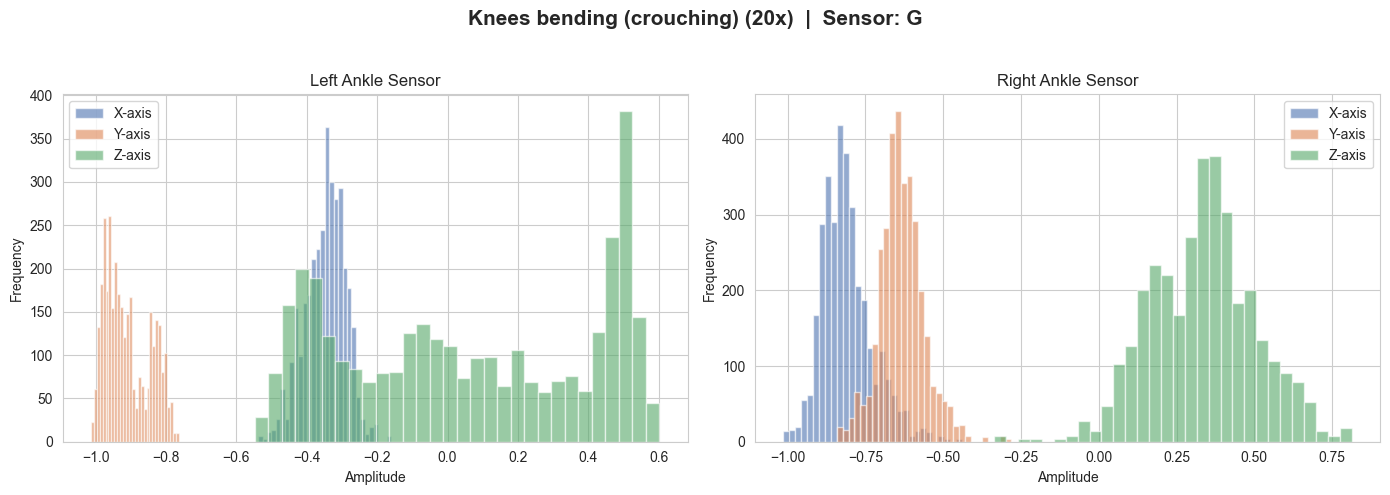

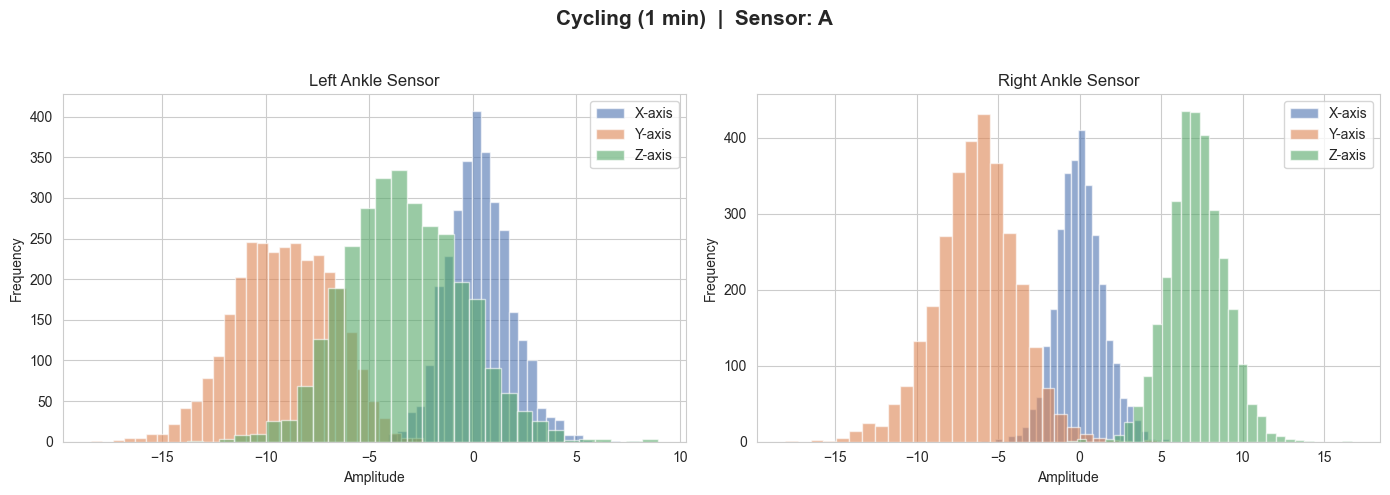

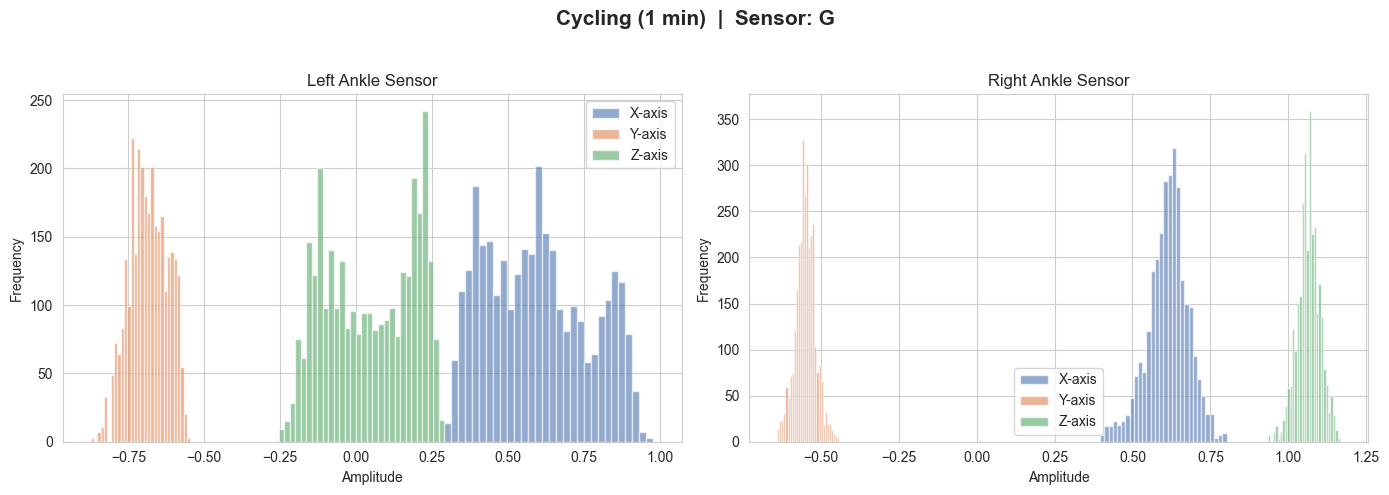

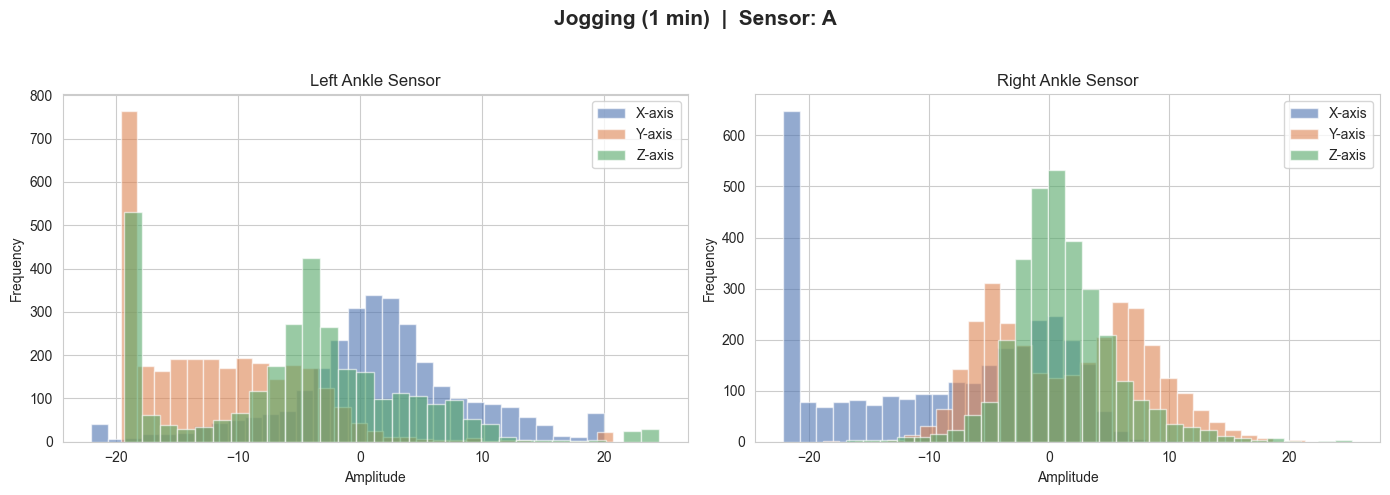

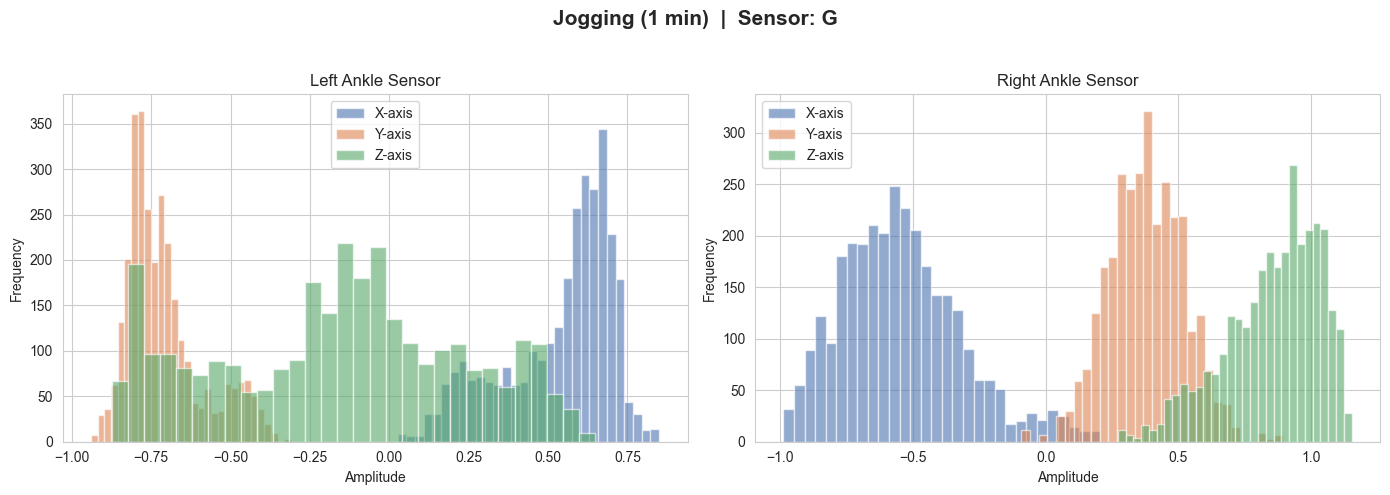

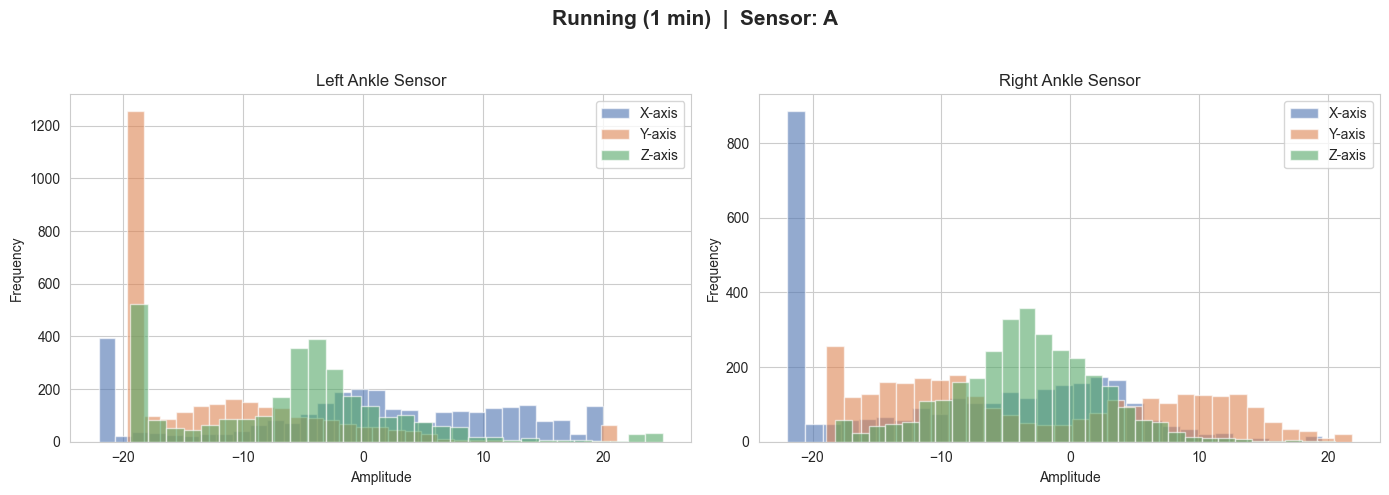

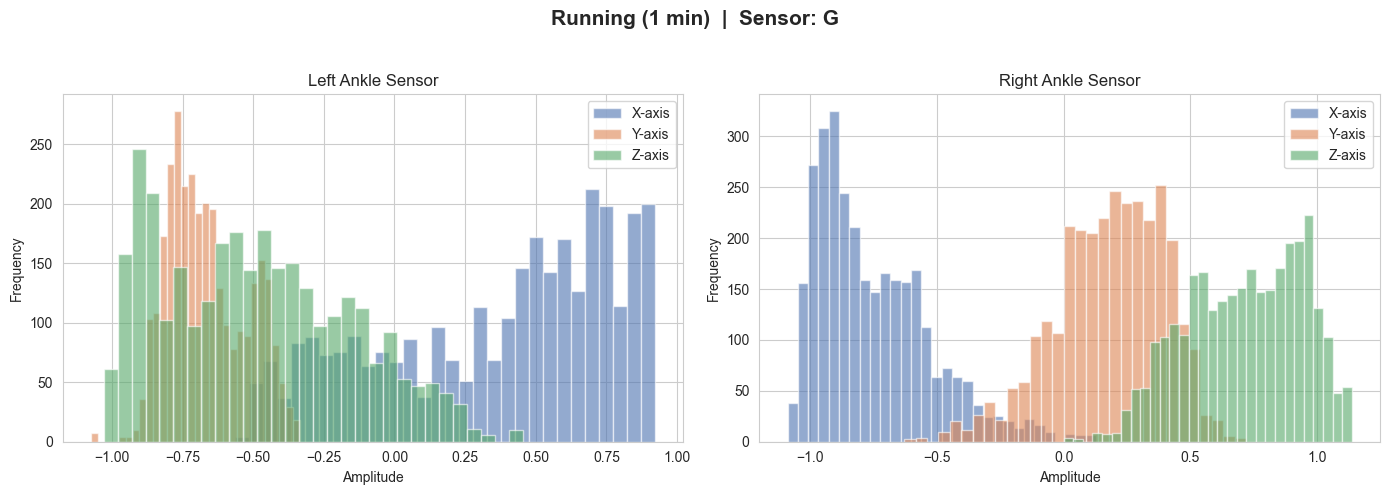

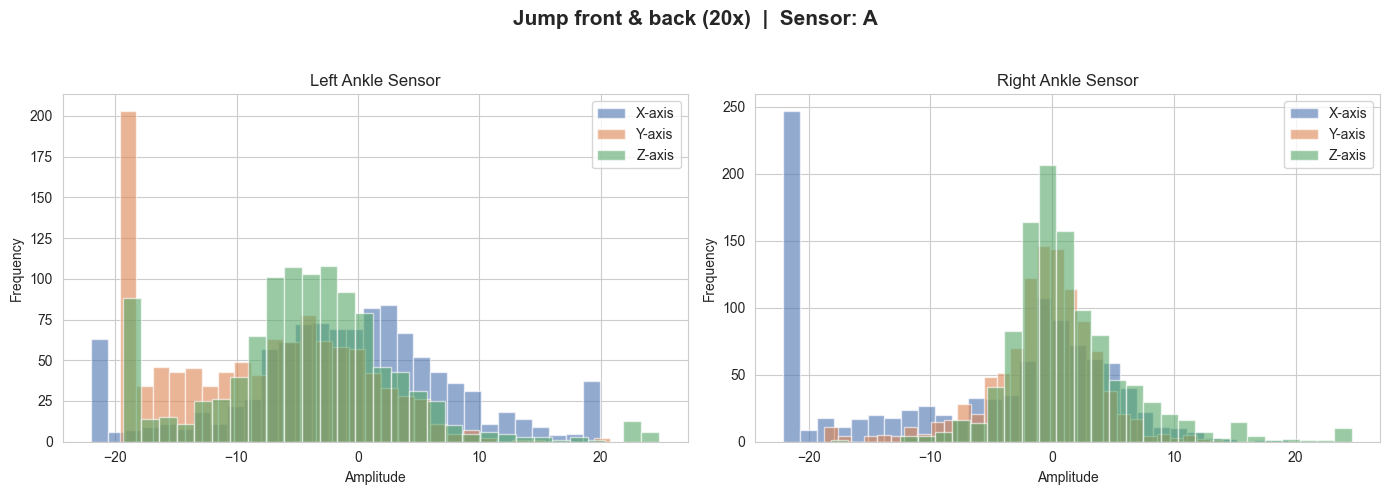

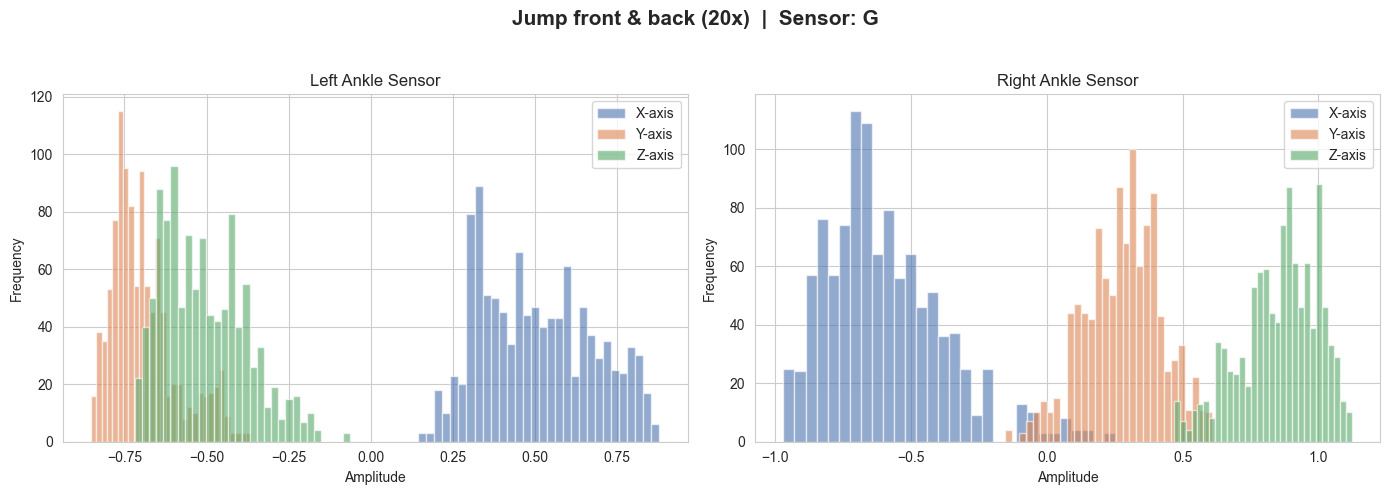

In [12]:
subject1 = df[df['subject'] == 'subject1']
readings = ['a', 'g']
sns.set_style("whitegrid")
for i in range(1, 13):
    for r in readings:
        fig, axes = plt.subplots(1, 2, figsize=(14,5))
        fig.suptitle(f"{act_label[i]}  |  Sensor: {r.upper()}", fontsize=15, fontweight="bold")
        sides = ['l','r']
        titles = ["Left Ankle Sensor", "Right Ankle Sensor"]
        colors = ["#4C72B0","#DD8452","#55A868"]
        for idx, side in enumerate(sides):
            ax = axes[idx]
            subset = subject1[subject1['Activity'] == i]
            if not subset.empty:
                ax.hist(subset[r+side+"x"], bins=30, alpha=0.6, color=colors[0], label="X-axis")
                ax.hist(subset[r+side+"y"], bins=30, alpha=0.6, color=colors[1], label="Y-axis")
                ax.hist(subset[r+side+"z"], bins=30, alpha=0.6, color=colors[2], label="Z-axis")
            ax.set_title(titles[idx], fontsize=12)
            ax.set_xlabel("Amplitude")
            ax.set_ylabel("Frequency")
            ax.legend(frameon=True)
        plt.tight_layout(rect=[0,0,1,0.95])
        plt.show()

In [13]:
df["Activity"] = df["Activity"].map(act_label)

In [14]:
df["Activity"].value_counts()

Activity
Standing Still (1 min)             30720
Lying Down (1 min)                 30720
Sitting and Relaxing (1 min)       30720
Walking (1 min)                    30720
Cycling (1 min)                    30720
Running (1 min)                    30720
Climbing stairs (1 min)            30720
Jogging (1 min)                    30720
None                               30000
Frontal elevation of arms (20x)    29441
Knees bending (crouching) (20x)    29337
Waist bends forward (20x)          28315
Jump front & back (20x)            10342
Name: count, dtype: int64

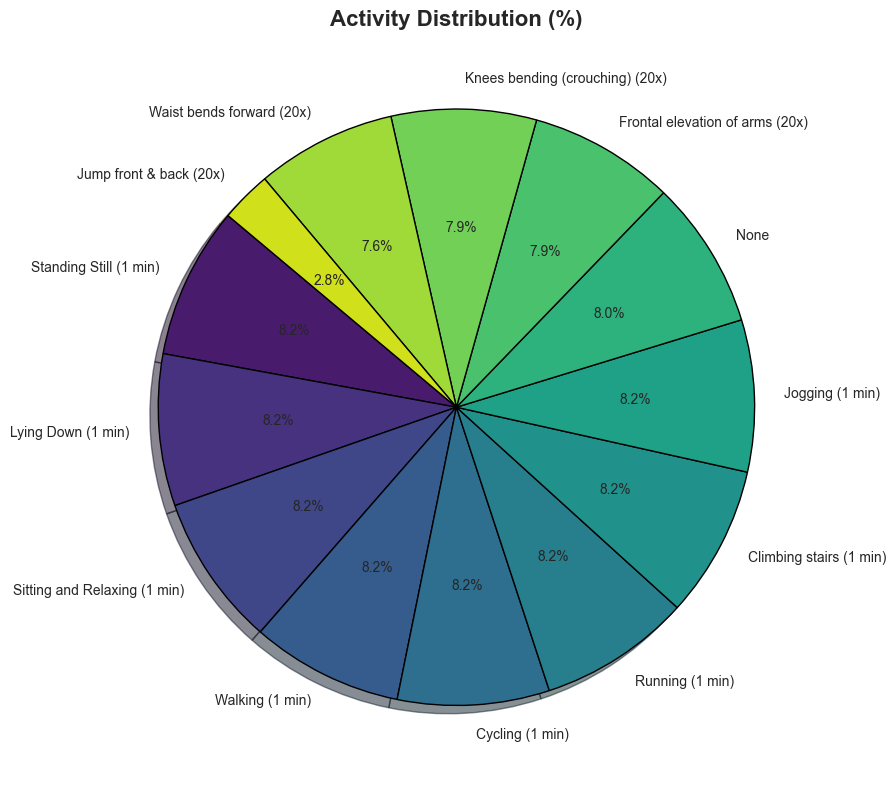

In [15]:
plt.figure(figsize=(12,8))
colors = sns.color_palette("viridis", len(df["Activity"].unique()))
(
    df["Activity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .plot.pie(
        autopct="%1.1f%%",
        startangle=140,
        colors=colors,
        shadow=True,
        wedgeprops={"edgecolor":"black","linewidth":1}
    )
)
plt.title("Activity Distribution (%)", fontsize=16, fontweight="bold")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [16]:
for feature in df.columns[:-2]:
    lower_range = np.quantile(df[feature], 0.01)
    upper_range = np.quantile(df[feature], 0.99)
    print(feature, "range:", lower_range, "to", upper_range)
    df = df.drop(
        df[(df[feature] > upper_range) | (df[feature] < lower_range)].index
    )
print("Shape:", df.shape)

alx range: -11.58706 to 19.233
aly range: -19.365 to 1.843305999999994
alz range: -18.607 to 11.861260000000009
glx range: -0.74768 to 0.7996300000000001
gly range: -1.0394 to 0.96998
glz range: -1.0963 to 0.82711
arx range: -21.469 to 6.8321640000000015
ary range: -18.685 to 10.915
arz range: -6.406619 to 10.293
grx range: -1.0059 to 0.89412
gry range: -1.1232 to 0.92197
grz range: -0.65086 to 1.1164
Shape: (293744, 14)


In [17]:
le = LabelEncoder()
df["subject"] = le.fit_transform(df["subject"])
df["Activity"] = le.fit_transform(df["Activity"])

<Figure size 2000x1500 with 0 Axes>

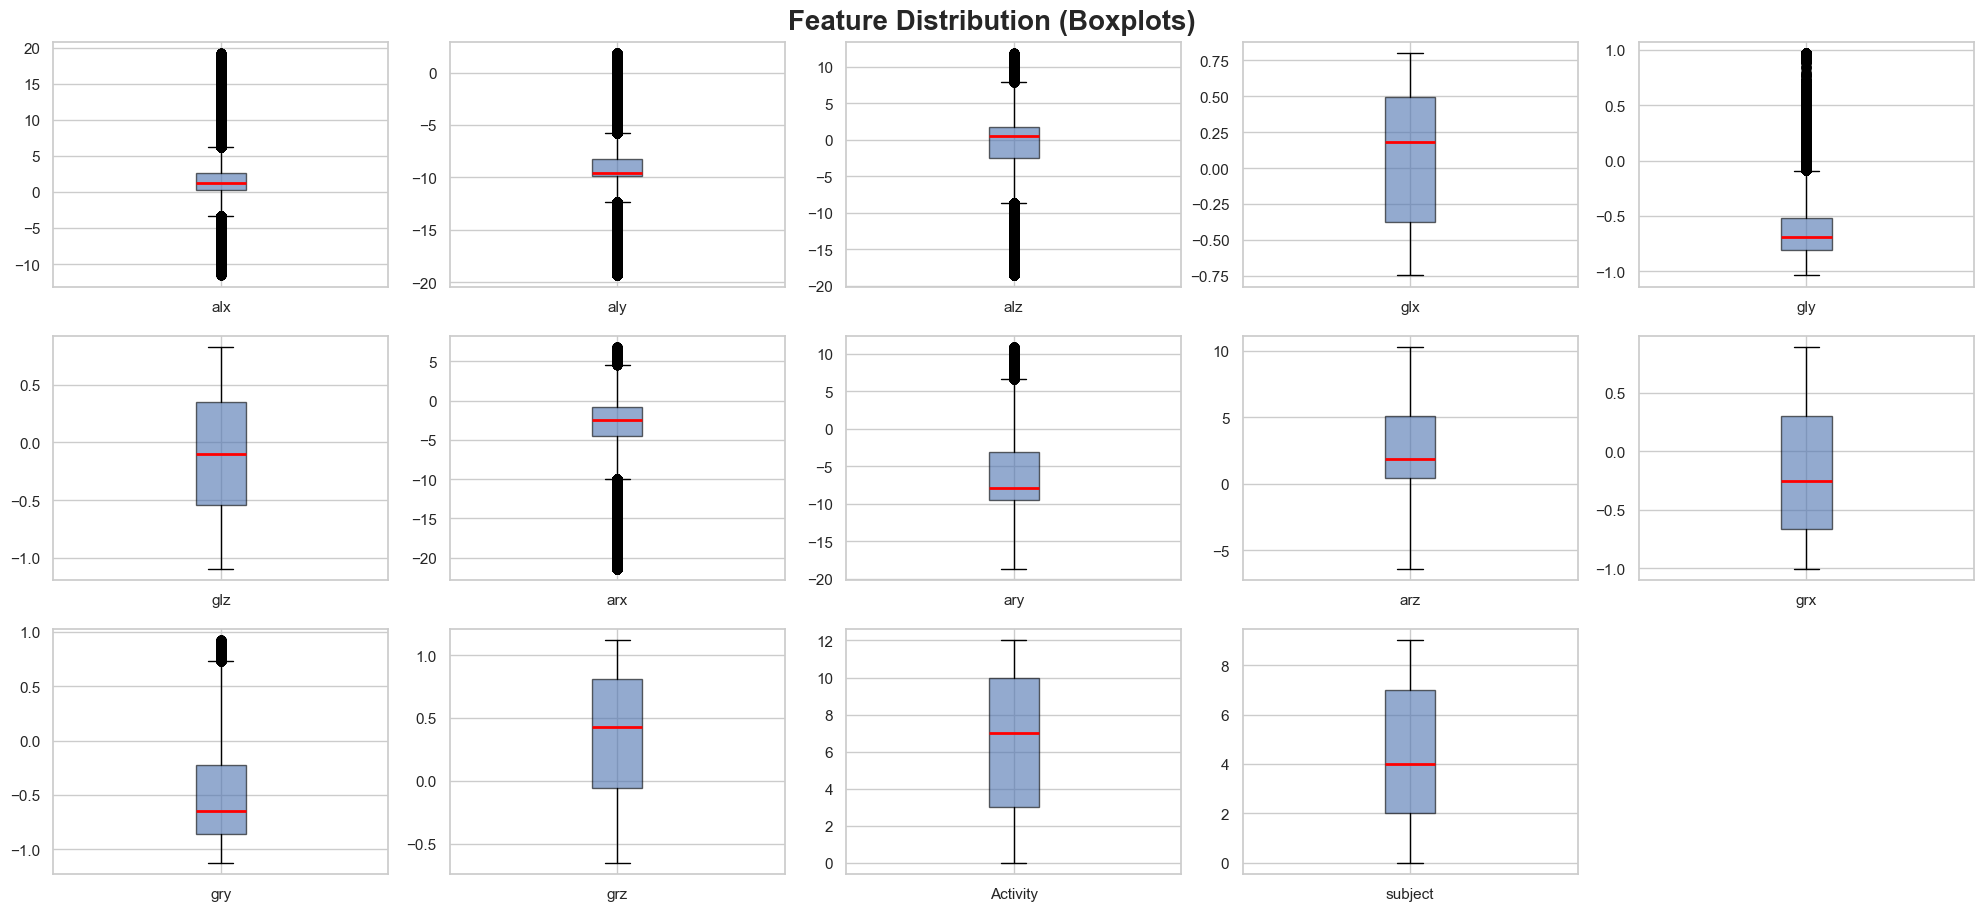

In [18]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20,15))
df.plot(
    kind="box",
    subplots=True,
    layout=(5,5),
    figsize=(20,15),
    patch_artist=True,
    boxprops=dict(facecolor="#4C72B0", alpha=0.6),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black")
)
plt.suptitle("Feature Distribution (Boxplots)", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
X = df.drop(columns = ["Activity", "subject"], axis = 1).values
y = df["Activity"].values

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42, stratify = y)  

In [21]:
ro = RobustScaler()
X_train_scaled = ro.fit_transform(X_train)
X_test_scaled = ro.transform(X_test)

In [22]:
def res(y_test, y_pred, t=True):
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro Precision: {prec:.4f}")
    print(f"Macro Recall: {rec:.4f}")
    print(f"Macro F1-score: {f1:.4f}")
    if t:
        plt.figure(figsize=(10,8))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap="Blues",
            xticklabels=list(act_label.values()),
            yticklabels=list(act_label.values())
        )
        plt.title("Confusion Matrix")
        plt.ylabel("Actual")
        plt.xlabel("Predicted")
        plt.show()

        print(classification_report(
            y_test,
            y_pred,
            target_names=list(act_label.values())
        ))

In [23]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
print("Training Accuracy:", lr.score(X_train_scaled, y_train))
print("Testing Accuracy:", lr.score(X_test_scaled, y_test))

Training Accuracy: 0.6378433829003032
Testing Accuracy: 0.6383245274797102


In [24]:
y_pred1 = lr.predict(X_test_scaled)
res(y_test, y_pred1, t = False)

Accuracy: 0.6383
Macro Precision: 0.6163
Macro Recall: 0.5985
Macro F1-score: 0.5891


In [25]:
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [26]:
y_pred2 = knn.predict(X_test_scaled)
res(y_test, y_pred2, t = False)

Accuracy: 0.9496
Macro Precision: 0.9417
Macro Recall: 0.9263
Macro F1-score: 0.9295


In [27]:
for i in range(1, 11):
    print("Neighbours :", i)
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    res(y_test, y_pred, t = False)
    print()

Neighbours : 1
Accuracy: 0.9492
Macro Precision: 0.9372
Macro Recall: 0.9287
Macro F1-score: 0.9315

Neighbours : 2
Accuracy: 0.9436
Macro Precision: 0.9307
Macro Recall: 0.9199
Macro F1-score: 0.9229

Neighbours : 3
Accuracy: 0.9496
Macro Precision: 0.9417
Macro Recall: 0.9263
Macro F1-score: 0.9295

Neighbours : 4
Accuracy: 0.9480
Macro Precision: 0.9403
Macro Recall: 0.9231
Macro F1-score: 0.9269

Neighbours : 5
Accuracy: 0.9473
Macro Precision: 0.9400
Macro Recall: 0.9230
Macro F1-score: 0.9263

Neighbours : 6
Accuracy: 0.9456
Macro Precision: 0.9387
Macro Recall: 0.9197
Macro F1-score: 0.9232

Neighbours : 7
Accuracy: 0.9439
Macro Precision: 0.9365
Macro Recall: 0.9182
Macro F1-score: 0.9213

Neighbours : 8
Accuracy: 0.9425
Macro Precision: 0.9359
Macro Recall: 0.9153
Macro F1-score: 0.9189

Neighbours : 9
Accuracy: 0.9414
Macro Precision: 0.9349
Macro Recall: 0.9141
Macro F1-score: 0.9176

Neighbours : 10
Accuracy: 0.9401
Macro Precision: 0.9338
Macro Recall: 0.9122
Macro F1-scor

In [28]:
dt = DecisionTreeClassifier(max_depth = 30, min_samples_split=3, random_state = 42)
dt.fit(X_train, y_train)
y_pred3 = dt.predict(X_test)
res(y_test, y_pred3, t = False)

Accuracy: 0.9336
Macro Precision: 0.9135
Macro Recall: 0.9138
Macro F1-score: 0.9135


In [29]:
rf = RandomForestClassifier(n_estimators = 100, max_depth = 30, min_samples_split = 3, random_state = 42)
rf.fit(X_train, y_train)
y_pred4 = rf.predict(X_test)
res(y_test, y_pred4, t = False)

Accuracy: 0.9734
Macro Precision: 0.9697
Macro Recall: 0.9635
Macro F1-score: 0.9651


In [30]:
cat = CatBoostClassifier(iterations=100, learning_rate=0.5, depth=10, verbose=0)
cat.fit(X_train_scaled, y_train)
y_pred5 = cat.predict(X_test_scaled)
res(y_test, y_pred5, t=False)

Accuracy: 0.9668
Macro Precision: 0.9606
Macro Recall: 0.9563
Macro F1-score: 0.9576


In [31]:
xg = XGBClassifier(n_estimators=100, learning_rate=0.5, max_depth=10, eval_metric="mlogloss")
xg.fit(X_train_scaled, y_train)
y_pred6 = xg.predict(X_test_scaled)
res(y_test, y_pred6, t=False)

Accuracy: 0.9782
Macro Precision: 0.9747
Macro Recall: 0.9709
Macro F1-score: 0.9720


In [32]:
lg = lgb.LGBMClassifier()
lg.fit(X_train_scaled, y_train)
y_pred7 = lg.predict(X_test_scaled)
res(y_test, y_pred7, t = False)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006526 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3059
[LightGBM] [Info] Number of data points in the train set: 220308, number of used features: 12
[LightGBM] [Info] Start training from score -2.599271
[LightGBM] [Info] Start training from score -2.495640
[LightGBM] [Info] Start training from score -2.483111
[LightGBM] [Info] Start training from score -2.865784
[LightGBM] [Info] Start training from score -4.108829
[LightGBM] [Info] Start training from score -2.322426
[LightGBM] [Info] Start training from score -2.501216
[LightGBM] [Info] Start training from score -2.606318
[LightGBM] [Info] Start training from score -3.410308
[LightGBM] [Info] Start training from score -2.271253
[LightGBM] [Info] Start training from score -2.257795
[LightGBM] [Info] Start training from score -2.368765
[LightGBM] [Info] Start training from score -2.321130
Accuracy

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best RF Score: 0.9711721771338307
Accuracy: 0.9748
Macro Precision: 0.9714
Macro Recall: 0.9654
Macro F1-score: 0.9671


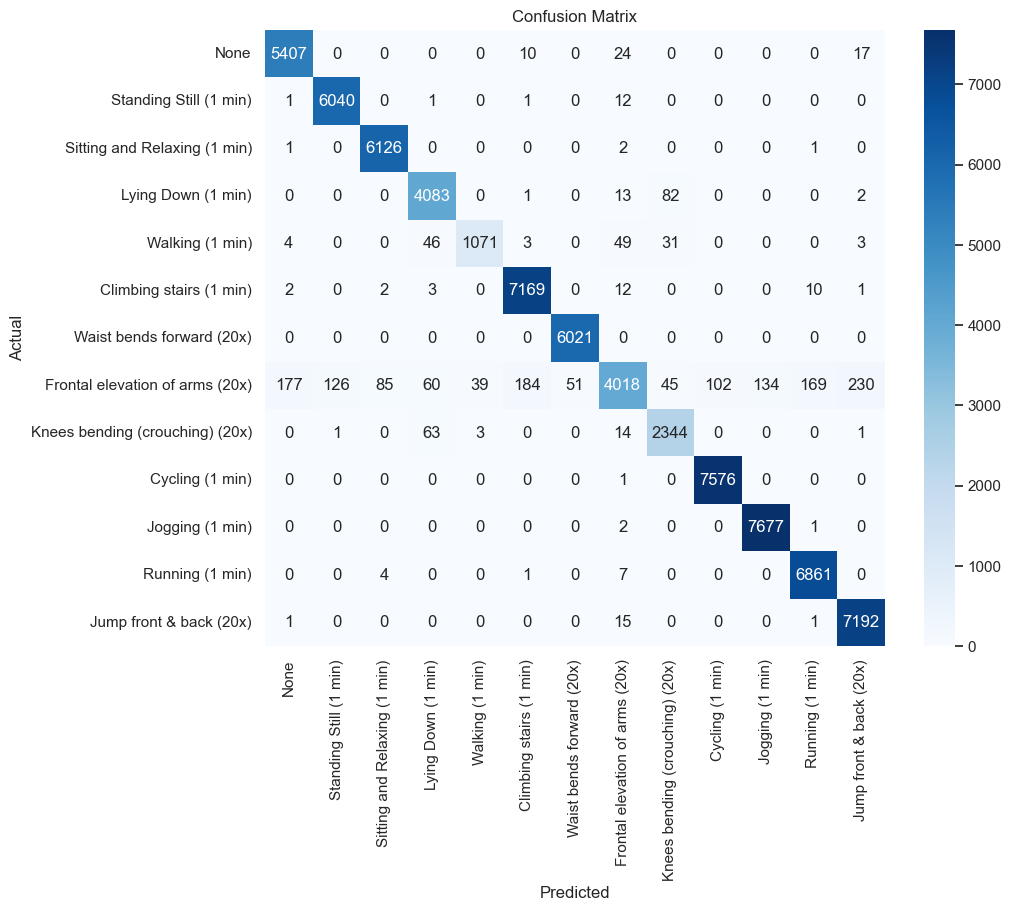

                                 precision    recall  f1-score   support

                           None       0.97      0.99      0.98      5458
         Standing Still (1 min)       0.98      1.00      0.99      6055
   Sitting and Relaxing (1 min)       0.99      1.00      0.99      6130
             Lying Down (1 min)       0.96      0.98      0.97      4181
                Walking (1 min)       0.96      0.89      0.92      1207
        Climbing stairs (1 min)       0.97      1.00      0.98      7199
      Waist bends forward (20x)       0.99      1.00      1.00      6021
Frontal elevation of arms (20x)       0.96      0.74      0.84      5420
Knees bending (crouching) (20x)       0.94      0.97      0.95      2426
                Cycling (1 min)       0.99      1.00      0.99      7577
                Jogging (1 min)       0.98      1.00      0.99      7680
                Running (1 min)       0.97      1.00      0.99      6873
        Jump front & back (20x)       0.97      1.

In [33]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [20, 30, 40, None],
    "min_samples_split": [2, 3, 5]
}
grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)
print("Best RF Params:", grid_rf.best_params_)
print("Best RF Score:", grid_rf.best_score_)
rf_best = grid_rf.best_estimator_
y_pred_rf = rf_best.predict(X_test)
res(y_test, y_pred_rf)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best XGB Params: {'learning_rate': 0.5, 'max_depth': 6, 'n_estimators': 300}
Best XGB Score: 0.9765555495034225
Accuracy: 0.9793
Macro Precision: 0.9761
Macro Recall: 0.9736
Macro F1-score: 0.9740


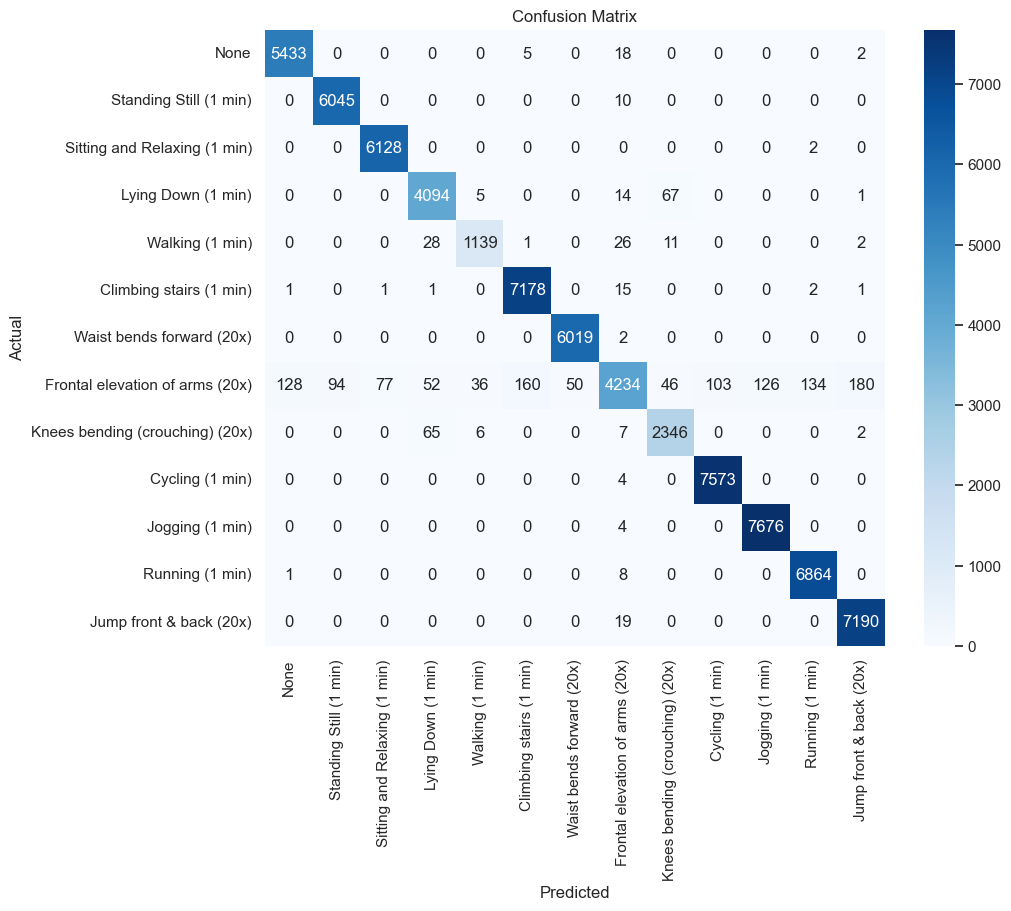

                                 precision    recall  f1-score   support

                           None       0.98      1.00      0.99      5458
         Standing Still (1 min)       0.98      1.00      0.99      6055
   Sitting and Relaxing (1 min)       0.99      1.00      0.99      6130
             Lying Down (1 min)       0.97      0.98      0.97      4181
                Walking (1 min)       0.96      0.94      0.95      1207
        Climbing stairs (1 min)       0.98      1.00      0.99      7199
      Waist bends forward (20x)       0.99      1.00      1.00      6021
Frontal elevation of arms (20x)       0.97      0.78      0.87      5420
Knees bending (crouching) (20x)       0.95      0.97      0.96      2426
                Cycling (1 min)       0.99      1.00      0.99      7577
                Jogging (1 min)       0.98      1.00      0.99      7680
                Running (1 min)       0.98      1.00      0.99      6873
        Jump front & back (20x)       0.97      1.

In [35]:
xg = XGBClassifier(eval_metric="mlogloss")

param_grid_xg = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1, 0.5],
    "max_depth": [6, 8, 10, 12]
}
grid_xg = GridSearchCV(
    xg,
    param_grid_xg,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)
grid_xg.fit(X_train_scaled, y_train)
print("Best XGB Params:", grid_xg.best_params_)
print("Best XGB Score:", grid_xg.best_score_)
xg_best = grid_xg.best_estimator_
y_pred_xg = xg_best.predict(X_test_scaled)
res(y_test, y_pred_xg)

In [37]:
scores = cross_val_score(
    xg_best,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())
print("Std deviation:", scores.std())

Cross-validation scores: [0.97737279 0.97862103 0.97787209 0.97748576 0.97841629]
Mean accuracy: 0.9779535922202574
Std deviation: 0.0004944499220435238


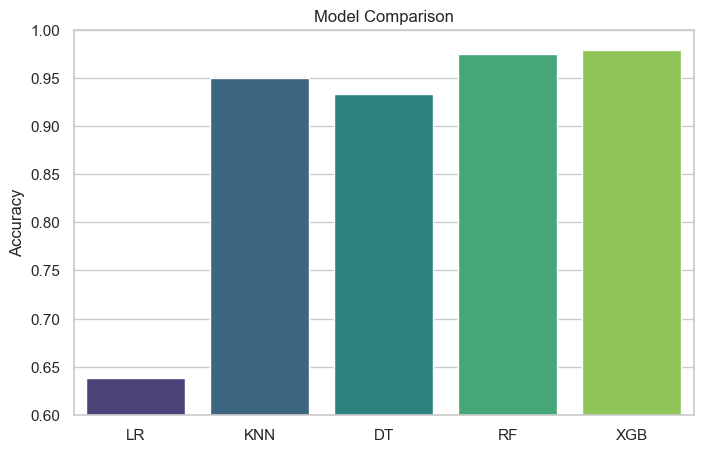

In [38]:
models = ["LR","KNN","DT","RF","XGB"]
acc = [0.6383,0.9496,0.9336,0.9748,0.9793]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=acc, palette="viridis")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.ylim(0.6,1)
plt.show()

### Best Model => XGBoost with

### n_estimators : 300

### max_depth : 6

### learning_rate : 0.5